<img src="https://drive.google.com/uc?export=view&id=1zpTTBMvqw3dHBkPGfqbndqqHiEYxG93X" width="300">

# Multi-Sensor Machine Learning for Flood Characterisation in South Yorkshire: Extent and Depth


---
### **GEOL0069 Final Project — Notebook 3 of 3**
## **Flood Depth Estimation: Comparing SAR, Optical, and Combined Approaches**
**Student ID: 25231865**

---

## Overview

Notebooks 1-2 established where the flood is, using SAR backscatter, terrain, and three classifiers, with proper spatial and temporal generalisation tests. This notebook attempts to address **how deep the floodwater is, and which data source tells us most about that.**

We have no direct depth measurements, so we use a DEM-derived **depth proxy** (Section 3.3) as a common reference target, and then compare four ways of estimating it:

| Approach | Inputs | Method |
|---|---|---|
| **A. SAR + terrain** | `VV_mid`, `VH_mid`, `VV_diff`, `VH_diff`, `elevation`, `slope` | GP regression (ARD) |
| **B. Optical / water-colour** | Sentinel-2 reflectance bands + NDWI, MNDWI, and a Stumpf-style blue:green ratio | GP regression (ARD) |
| **C. Combined** | A + B together | GP regression (ARD) |
| **D. Unsupervised cross-check** | Optical features only, no depth labels | K-means clustering |

**Why we use optical reflectance for depth:** Shallow, turbid floodwater over agricultural land tends to be brighter and more sediment-coloured (higher blue/green reflectance), while deeper, clearer water absorbs more in the red/NIR and looks darker. This is the same logic behind established shallow-water bathymetry techniques, in particular the blue:green log-ratio 'ratio' algorithm of Stumpf, Holderied & Sinclair (2003, *Limnology and Oceanography*, 48(1), 547-556), developed for clear coastal water. We cannot (and do not) assume this transfers unchanged to turbid floodwater over fields. This assumption is tested by Approaches B and C test.

**Caveat for Notebook 3**: the Sentinel-2 scene used here was captured some days (~10) after the SAR mid-flood image (see Notebook 1), because cloud cover at the flood peak made earlier optical scenes unusable. This is in itself relevant to the SAR-vs-optical debate from Section 1.1, as SAR sees through cloud, while optical doesn't. We must consider that the two sensors are providing information about two slightly different moments.

## What this notebook does

| Step | Description |
|---|---|
| 3.1 | Load data from Notebooks 1-2 (feature stack + Sentinel-2 bands) |
| 3.2 | Optical water-colour features (NDWI, MNDWI, Stumpf ratio) |
| 3.3 | Depth proxy (Height Above Nearest Dry Pixel): the common regression target |
| 3.4 | Three GP regression approaches: SAR+terrain, optical, combined |
| 3.5 | Performance comparison (RMSE, R^2) |
| 3.6 | What each approach relies on (ARD lengthscale comparison) |
| 3.7 | Full depth + uncertainty maps for the best-performing approach |
| 3.8 | Unsupervised cross-check: K-means on water-colour features |
| 3.9 | XAI cross-check: SHAP on a Random Forest depth regressor |
| 3.10 | Environmental cost |
| 3.11 | Conclusions, limitations, and real-world quantification |

---

*GEOL0069 Final Project | UCL AI for Earth Observation 2025/26*

[GEOL0069 @ UCL 2025/26](https://github.com/CPOMUCL/GEOL0069-AI4EO)

---

In [15]:
# Mount Google Drive
# this allows us to access files from previous notebooks
# and save new output
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# shap:       explainability (inspired by Week 9 AI4EO module)
# codecarbon: emissions tracking
# GP regression uses scikit-learn's GaussianProcessRegressor with an ARD RBF
# kernel (already installed in Colab) - this avoids GPy's numpy<2.0 /
# scipy<=1.12 requirement, which conflicts with the numpy>=2 that shap and
# other packages in the current Colab image require
# In this project, we initially tried to use GPy, but encountered this version conflict

!pip install shap -q
!pip install codecarbon -q

print("Packages installed.") # Make sure as always!

Packages installed.


In [17]:
# Import the usual libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# distance_transform_edt is for finding coordinates of every pixel in binary mask's distance to nearest pixel of other class
# Used in depth-proxy calculation in Section 3.3 - looking at nearest dry pixel to flooded ones
from scipy.ndimage import distance_transform_edt

from sklearn.preprocessing import StandardScaler # rescales features to mean 0
from sklearn.ensemble import RandomForestRegressor # in section 3.9, used for SHAP cross-check
from sklearn.cluster import KMeans # in section 3.8, unsupervised clustering on optical features
from sklearn.model_selection import train_test_split # evaluation for the GP regression
from sklearn.metrics import mean_squared_error, r2_score # evaluation for the GP regressions

# Regression model, GaussianProcessRegressor, and requirements for its kernel function
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

import shap # section 3.9 - SHapley Additive exPlanations, explaining individual predictions of trained model

from codecarbon import EmissionsTracker

# Same project paths as first 2 notebooks
BASE_DIR = '/content/drive/MyDrive/AI4EO/Final_Project'
DIRS = {
    'processed': os.path.join(BASE_DIR, 'data', '01_processed'),
    'features':  os.path.join(BASE_DIR, 'data', '02_features'),
    'figures':   os.path.join(BASE_DIR, 'figures'),
    'results':   os.path.join(BASE_DIR, 'results'),
}
for p in DIRS.values():
    os.makedirs(p, exist_ok=True)

print("Imports successful.")
print(f"NumPy: {np.__version__}") # Check your versions + be mindful of any errors
print(f"SHAP:  {shap.__version__}")

Imports successful.
NumPy: 2.0.2
SHAP:  0.52.0


## 3.1 Load Data from Notebooks 1-2

We load the training-scene feature stack and labelling from Notebook 2's `feature_stack.npz`, and the Sentinel-2 bands from Notebook 1's `flood_data.npz`. Shapes are cropped to a common (H, W) in case the two sources differ by a pixel or two at the AOI edges.

In [18]:
feat_path = os.path.join(DIRS['features'], 'feature_stack.npz') # Notebook 2's output
nb1_path  = os.path.join(DIRS['processed'], 'flood_data.npz') # Notebook 1's output

# Check if both notebook's have been successfully run:
for p in (feat_path, nb1_path):
    if not os.path.exists(p):
        raise FileNotFoundError(f"{p} not found. Please run Notebooks 1 and 2 first.")

feat_data = np.load(feat_path, allow_pickle=True)
nb1_data  = np.load(nb1_path, allow_pickle=True)

# everything that notebook 2 calculated about training scene is loaded
# 9 feature cube, validity mask, threshold baseline mask, etc
cube_train       = feat_data['cube_train']
valid_train      = feat_data['valid_train']
thresholdbaseline_train      = feat_data['thresholdbaseline_train']
confident_train  = feat_data['confident_train']
ambiguous_train  = feat_data['ambiguous_train']
best_pred_map    = feat_data['best_pred_map']
best_model_name  = str(feat_data['best_model_name'][0])
FEATURE_NAMES    = [str(f) for f in feat_data['feature_names']]
SCALE            = int(feat_data['scale'][0])

# The five sentinel-2 reflectance bands for the training scene
# 'raw' because they haven't yet been cropped to match cube_train's shape
B2_raw  = nb1_data['train_B2']
B3_raw  = nb1_data['train_B3']
B4_raw  = nb1_data['train_B4']
B8_raw  = nb1_data['train_B8']
B11_raw = nb1_data['train_B11']
s2_date = str(nb1_data['s2_date'][0])

print(f"Feature stack:  cube_train {cube_train.shape}, feature names {FEATURE_NAMES}")
print(f"Sentinel-2:     {B2_raw.shape}, scene date {s2_date}")
print(f"Best classifier from Notebook 2 (for reference): {best_model_name}")

# Crop everything to a common (H, W)
# Take the smaller of each dimension + crop everything to that (H, W)
H = min(cube_train.shape[0], B2_raw.shape[0])
W = min(cube_train.shape[1], B2_raw.shape[1])

cube_train      = cube_train[:H, :W]
valid_train     = valid_train[:H, :W]
thresholdbaseline_train     = thresholdbaseline_train[:H, :W]
confident_train = confident_train[:H, :W]
ambiguous_train = ambiguous_train[:H, :W]
best_pred_map   = best_pred_map[:H, :W]

# a tuple of the 5 raw band arrays - able to apply same [:H, :W] slice to all 5 without writing out 5 times
B2, B3, B4, B8, B11 = [b[:H, :W] for b in (B2_raw, B3_raw, B4_raw, B8_raw, B11_raw)]

print(f"\nCropped to common shape: ({H}, {W})")
print(f"Threshold Baseline flooded pixels: {int(thresholdbaseline_train[valid_train].sum()):,}")

Feature stack:  cube_train (280, 273, 9), feature names ['VV_pre', 'VH_pre', 'VV_mid', 'VH_mid', 'VV_diff', 'VH_diff', 'VV_VH_ratio_mid', 'elevation', 'slope']
Sentinel-2:     (286, 273), scene date 2019-11-18
Best classifier from Notebook 2 (for reference): Random Forest

Cropped to common shape: (280, 273)
Threshold Baseline flooded pixels: 2,343


## 3.2 Optical Water-Colour Features

From the five Sentinel-2 bands we calculate three established water indices/ratios:

- **NDWI** = (Green - NIR) / (Green + NIR) - [McFeeters (1996)](https://doi.org/10.1080/01431169608948714), sensitive to open water vs land.
- **MNDWI** = (Green - SWIR1) / (Green + SWIR1) - [Xu (2006)](https://doi.org/10.1080/01431160600589179), generally more robust than NDWI over turbid water, since SWIR is even more strongly absorbed by water than NIR.
- **Stumpf ratio** = ln(Blue) / ln(Green) - the log band-ratio from [Stumpf et al. (2003)](https://doi.org/10.4319/lo.2003.48.1_part_2.0547), originally for clear-water bathymetry. Whether it carries useful depth information in turbid floodwater is part of what we're testing.

A combined valid mask (`valid_all`) excludes any pixel with a NaN in either the SAR/DEM cube or the optical bands.

Valid pixels (SAR/DEM + optical): 76,440 / 76,440


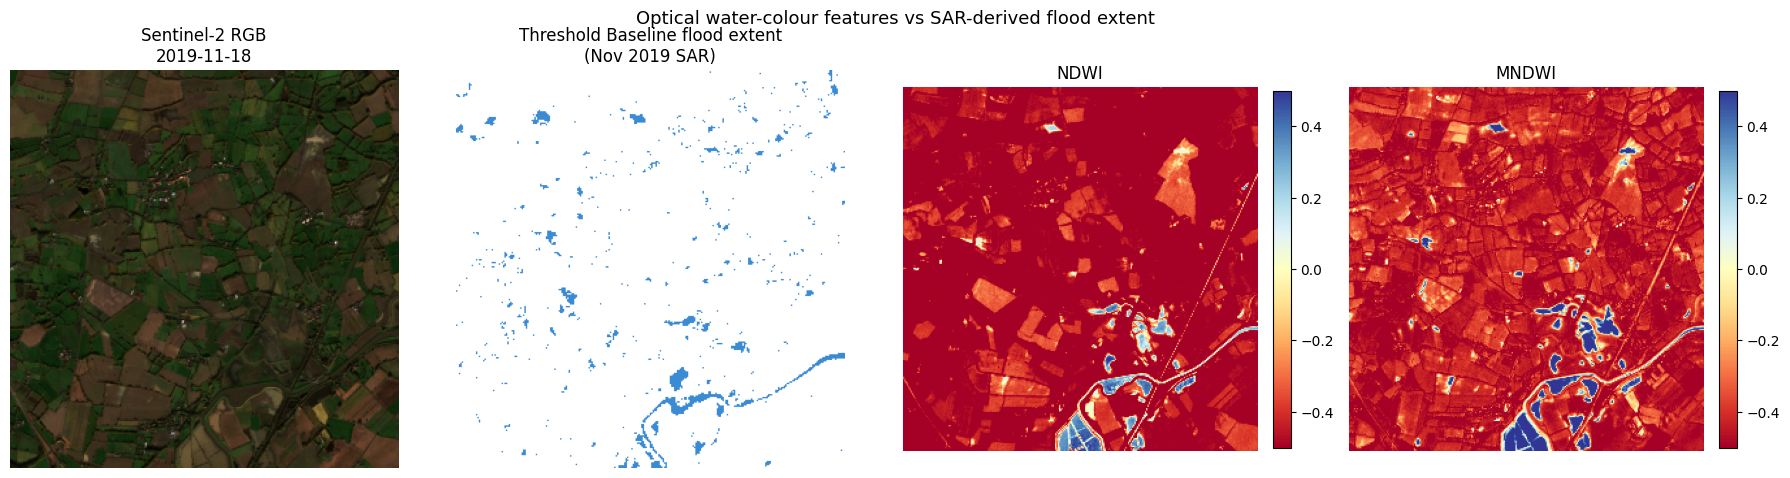

In [19]:
# Three water-colour indices/ratios computed pixel-by-pixel from the Sentinel-2 reflectance bands

# NDWI (Normalised Difference Water Index, McFeeters 1996): water absorbs
# strongly in the near-infrared (B8) but reflects more in green (B3), so
# water pixels have B3 > B8 -> positive NDWI; land is the opposite ->
# negative NDWI. The "+1e-9" in the denominator is a tiny constant added
# just to avoid a divide-by-zero error if B3+B8 happens to be exactly 0
# for some pixel. It has negligible effect on the result otherwise
NDWI  = (B3 - B8) / (B3 + B8 + 1e-9)

# MNDWI (Modified NDWI, Xu 2006): same idea as NDWI but using shortwave-
# infrared (B11) instead of near-infrared. SWIR is even more strongly
# absorbed by water than NIR, which may make MNDWI more robust than NDWI over
# turbid/sediment-laden water - relevant for floodwater, which is rarely clear
MNDWI = (B3 - B11) / (B3 + B11 + 1e-9)

# The Stumpf et al. (2003) log band-ratio: ln(Blue) / ln(Green)
# Originally designed for shallow-water bathymetry in clear coastal water, where the
# ratio of how much blue vs green light penetrates and returns relates to
# depth. np.clip(B2, 1e-4, None) and np.clip(B3, 1e-4, None) floor the
# reflectance values at a tiny positive number before taking the log
# ln(0) is undefined (-infinity), and reflectance values of exactly 0 can
# occur at the edges of the valid data range
STUMPF_RATIO = np.log(np.clip(B2, 1e-4, None)) / np.log(np.clip(B3, 1e-4, None))

# A list of names (for iterating over later) and a dictionary mapping each name to its (H, W) array
# so every optical feature can be looked up by name alongside the SAR/terrain features from the cube
OPTICAL_FEATURE_NAMES = ['B2', 'B3', 'B4', 'B8', 'B11', 'NDWI', 'MNDWI', 'STUMPF_RATIO']
optical_arrays = {
    'B2': B2, 'B3': B3, 'B4': B4, 'B8': B8, 'B11': B11,
    'NDWI': NDWI, 'MNDWI': MNDWI, 'STUMPF_RATIO': STUMPF_RATIO,
}

# Stack the 5 raw bands along a new axis + check for NaNs
optical_stack = np.stack([B2, B3, B4, B8, B11], axis=-1)
# STUMPF_RATIO is checked separately because its a derived quantity
valid_optical = ~np.any(np.isnan(optical_stack), axis=-1) & ~np.isnan(STUMPF_RATIO)
# Combines Notebook 2's SAR/DEM validity mask with this notebook's optical validity mask
# from here onwards, we use valid_all instead of valid_train
valid_all = valid_train & valid_optical

print(f"Valid pixels (SAR/DEM + optical): {valid_all.sum():,} / {valid_all.size:,}")

# Visualise the optical indices alongside Threshold Baseline
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# True colour composite of Sentinel-2 for reference
rgb = np.clip(np.stack([B4, B3, B2], axis=-1) * 3.5, 0, 1)
axes[0].imshow(rgb)
axes[0].set_title(f'Sentinel-2 RGB\n{s2_date}')

# 2-colour map: white= not flooded, blue= flooded
cmap_flood = mcolors.ListedColormap(['#FFFFFF', '#3B8BD4'])
axes[1].imshow(np.where(valid_all, thresholdbaseline_train.astype(float), np.nan), cmap=cmap_flood, vmin=0, vmax=1)
axes[1].set_title('Threshold Baseline flood extent\n(Nov 2019 SAR)')

# NDWI and MNDWI, displayed with a diverging red-yellow-blue colourmap
# centred near 0 (vmin=-0.5, vmax=0.5) - blue = more water-like, red = more
# land-like, for both indices
im2 = axes[2].imshow(np.where(valid_all, NDWI, np.nan), cmap='RdYlBu', vmin=-0.5, vmax=0.5)
axes[2].set_title('NDWI')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(np.where(valid_all, MNDWI, np.nan), cmap='RdYlBu', vmin=-0.5, vmax=0.5)
axes[3].set_title('MNDWI')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')
# Formatting details about the overall plot
# Showing Sentinel 2 RFB, Threshold Baseline flood extent, and calculated NDWI and MNDWI
plt.suptitle('Optical water-colour features vs SAR-derived flood extent', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig13_optical_features.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Figure Observations 10:**
>
> - NDWI and MNDWI both highlight broadly the same regions as the SAR Threshold Baseline (panel 2) and the visible river corridor in the RGB composite. This means three independent sources (SAR change-detection, NDWI, MNDWI) converge on a relatively consistent flood location.
> - Both optical indices render the river channel as a thicker, more continuous blue ribbon than the comparatively thin, patchy SAR-flagged pixels along the same stretch. This likely the fact that NDWI/MNDWI are continuous reflectance-based indices rather than the SAR Threshold Baseline's conservative two-condition binary cutoff.
> - MNDWI shows a marginally larger and darker water-like extent than NDWI along the same river stretch, consistent with the rationale given in Section 3.2 that SWIR-based MNDWI is often more robust than NIR-based NDWI over turbid or vegetated water.
> - A small number of field patches appear water-like in NDWI/MNDWI that don't appear in the SAR image. This may represent a false-positive pattern for NDWI/MNDWI, due to wet bare soil, shadow, or certain crop types, which can spectrally resemble water without actually being a flood. Alternatively, these could have been flooding features missed by the SAR threshold.

## 3.3 Flood Depth Proxy: Height Above Nearest Dry Pixel

We have no direct depth measurement, so we use a simplified **Height Above Nearest Drainage (HAND)**-style proxy, computed once and used as the common regression target for all three GP approaches:

$$\text{depth proxy} = \text{elevation of nearest dry pixel} - \text{elevation of this pixel}$$

The flood extent this proxy is computed over starts from **Threshold Baseline** (the SAR-threshold baseline from Notebook 1), but cannot be used directly: Threshold Baseline consists of hundreds of small, often single-pixel detections, and for an isolated flooded pixel the "nearest dry pixel" is, almost by definition, immediately adjacent at nearly the same elevation, giving a depth proxy of ~0 regardless of the true situation.

We therefore apply a morphological closing (merging nearby detections into more coherent water bodies) and discard any remaining blob below a minimum size, before computing the proxy.

The DEM itself is also lightly smoothed: on a floodplain this flat, pixel-to-pixel DEM noise can exceed the true elevation difference between a flooded pixel and its nearest dry neighbour, which would otherwise dominate the proxy. The cleaned flood extent and smoothed DEM are shown alongside the resulting depth proxy below.

This target doesn't depend on which model performed best in the Notebook 2 classification comparison. As before, this is a relative proxy, not a validated absolute depth: it is the common reference against which we compare how input features predict specific targets.

Note: even after cleanup and smoothing, nearly half of all flooded pixels still get a depth proxy of exactly zero, and the maximum across the whole AOI is under 2 m. This is consistent with Fishlake's floodplain being extremely flat, and therefore there simply isn't much elevation relief for a DEM-derived proxy to work with.

This is a significant complication of using this methodology, particularly when researching a terrain this flat. In this setting, **DEM-derived depth proxies are close to their limit of usefulness**, which motivates comparing how effective water-colour-based approaches are against this same proxy (Sections 3.4-3.6). Floodplains are, essentially by definition, among the areas most susceptible to this kind of flooding, so it is important to explore a variety depth-estimation methods in this setting.

Raw Threshold Baseline flooded pixels:           2,343
After morphological closing:         3,200
After dropping blobs < 9 px:   2,768 (59 of 278 regions kept)

Depth proxy computed for 2,768 flooded pixels (DEM smoothed, sigma=1.5)
  Min:    0.000 m
  Mean:   0.084 m
  Median: 0.006 m
  Max:    1.792 m
  Std:    0.180 m
  Fraction exactly 0: 47.9%


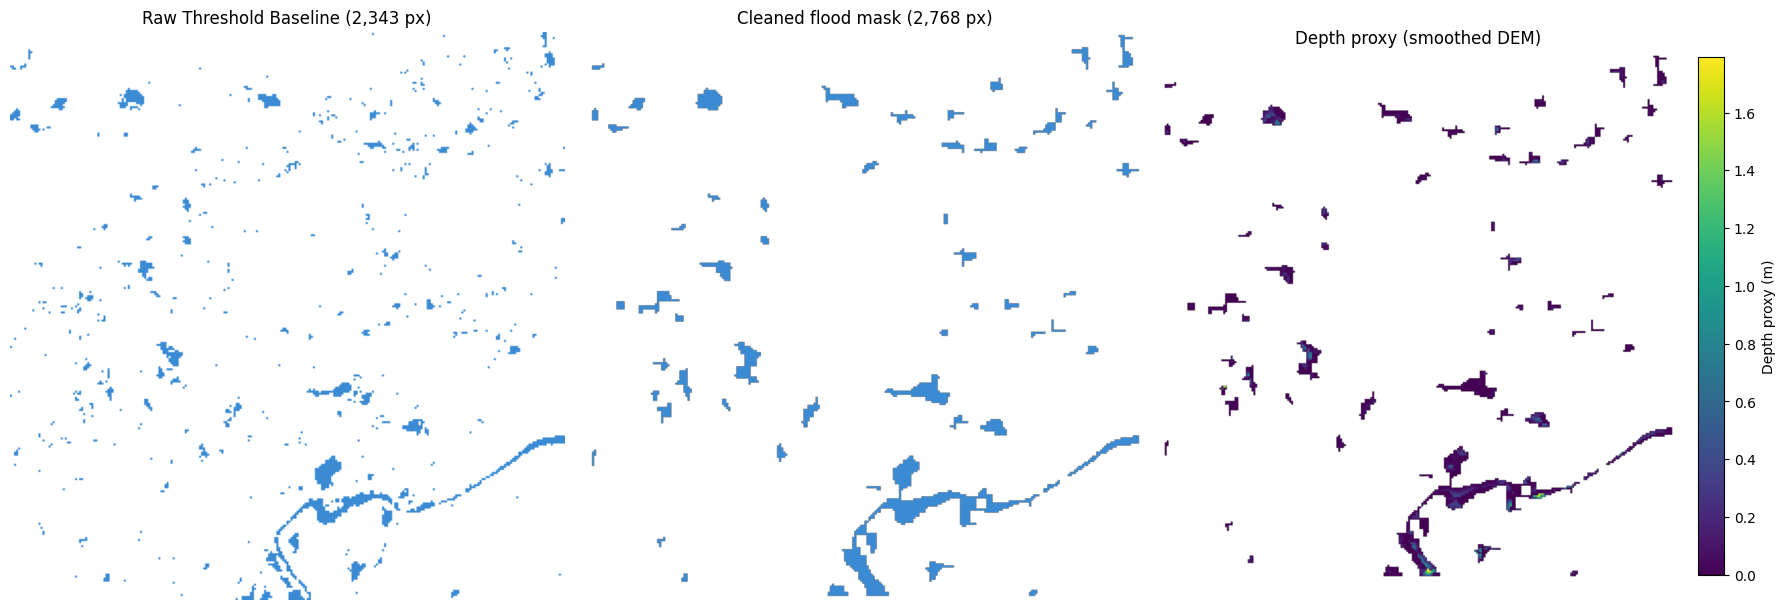

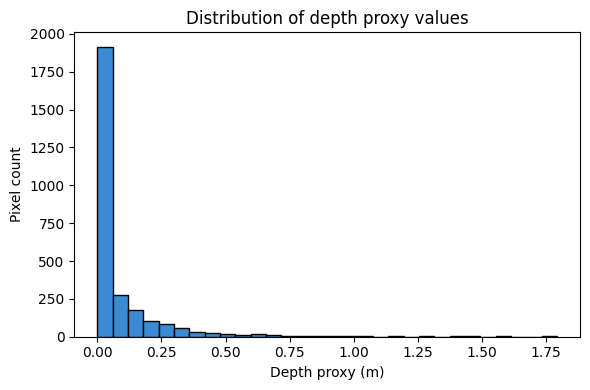

In [20]:

from scipy.ndimage import binary_closing, label, gaussian_filter
# Definitions of these imports:

# binary_closing = a morphological operation that dilates (grows) a binary
#   mask and then erodes (shrinks) it back by the same amount. The net
#   effect is to fill in small gaps/holes and merge nearby blobs that are
#   separated by only a pixel or two, without significantly changing the
#   overall size/shape of larger regions

# label = connected-component labelling. When given a binary mask, assigns a
#   unique integer ID (1, 2, 3, etc) to each separate contiguous 'blob' of
#   True pixels, and 0 to the background. Lets us measure/filter blobs individually

# gaussian_filter = smooths an array by averaging each pixel with its
#   neighbours, weighted by a Gaussian (bell-curve) function of distance:
#   used below to remove pixel-scale DEM noise

# The Threshold Baseline mask, restricted to pixels with complete data
raw_flood_mask = thresholdbaseline_train & valid_all

# 'binary_closing' = we apply morphological closing: structure=np.ones((3,3)) means the operation
# considers all 8 neighbours of each pixel (a full 3x3 block)
# iterations=2 applies the dilate-then-erode cycle twice, for a slightly stronger
# gap-filling effect than a single pass
# "& valid_all" afterwards ensures closing can't expand the mask
# into pixels we don't have complete data for (e.g. right at the AOI edge).

# This is because the raw Threshold Baseline is hundreds of small (often single-pixel)
# scattered detections. For the depth proxy below (distance to nearest dry
# pixel), an isolated flooded pixel is by definition immediately next to a
# dry pixel at nearly the same elevation, giving a depth of ~0 regardless
# of the true situation. Closing merges nearby detections into more
# coherent 'blobs' that can have meaningful interior pixels
closed = binary_closing(raw_flood_mask, structure=np.ones((3, 3)), iterations=2) & valid_all

labeled, n_components = label(closed)
component_sizes = np.bincount(labeled.ravel())
# np.bincount counts how many times each integer value appears in labeled.ravel() (1D array)

# Discard any blob smaller than this number (9) of pixels
# Treated as sub-pixel noise rather than meaningful standing water body
MIN_BLOB_PIXELS = 9
keep_labels = [i for i in range(1, n_components + 1) if component_sizes[i] >= MIN_BLOB_PIXELS]
# range (1, n_components +1) deliberately starts at 1, skipping label 0 (background)
# otherwise we would accidentally mark whole image as flooded
flood_mask = np.isin(labeled, keep_labels) # True wherever label meets conditions set out
dry_mask = valid_all & ~flood_mask # everything else that's still valid (wasn't identified for last step)

print(f"Raw Threshold Baseline flooded pixels:           {raw_flood_mask.sum():,}")
print(f"After morphological closing:         {closed.sum():,}")
print(f"After dropping blobs < {MIN_BLOB_PIXELS} px:   {flood_mask.sum():,} "
      f"({len(keep_labels)} of {n_components} regions kept)")

# FEATURE_NAMES.index finds position of elevation in list (7 now)
#  this is good because it still works even if order changes
DEM = cube_train[:, :, FEATURE_NAMES.index('elevation')]
# we fill any invalid pixels with the AOI's mean elevation
DEM_filled = np.where(valid_all, DEM, np.nanmean(DEM[valid_all]))

# -----------------------------------------------------------------------------
# SMOOTH THE DEM BEFORE COMPUTING THE DEPTH PROXY
#
# Fishlake's floodplain is extremely flat (elevation varies by only a few
# metres across the whole AOI). At that scale, pixel-to-pixel noise in the
# 20 m DEM can exceed the true elevation difference between a flooded pixel
# and its nearest dry neighbour, so "nearest dry elevation - own elevation"
# is often slightly negative and gets clipped to exactly 0 by noise alone --
# not because the true depth is zero. A light Gaussian smoothing of the DEM
# (sigma ~1.5 px = 30 m) removes pixel-scale noise while preserving the
# broader topographic gradient (e.g. the slope down towards the river).
# -----------------------------------------------------------------------------

# sigma is in pixels (1.5 px = 30m at 20m resolution)
# large sigma = more smoothing, affects width of Gaussian averaging window
DEM_SMOOTH_SIGMA = 1.5
DEM_smooth = gaussian_filter(DEM_filled, sigma=DEM_SMOOTH_SIGMA)

# Returns the (row, col) coordinates of the nearest background (aka dry) pixel
# '_' discards first return value - we only need coordinates, not distances
_, nearest_dry_idx = distance_transform_edt(flood_mask, return_indices=True)
# This provides for new entry to a new (H, W) array
# holds the smoothed elevation of the specific pixel/position (r, c)'s nearest dry pixel
DEM_nearest_dry = DEM_smooth[nearest_dry_idx[0], nearest_dry_idx[1]]

# Depth proxy calculation
depth_proxy_full = np.clip(DEM_nearest_dry - DEM_smooth, 0, None) #  0 is floor value - not interested in negative values
# not useful to know if the nearest dry pixel is lower in elevation so we just make that 0

# Restrict the result to flooded pixels only, everywhere else becomes NaN
# dry pixels would be their own closest dry pixel so not worth including
depth_proxy_full = np.where(flood_mask, depth_proxy_full, np.nan)

print(f"\nDepth proxy computed for {flood_mask.sum():,} flooded pixels (DEM smoothed, sigma={DEM_SMOOTH_SIGMA})")
# each function has 'nan' in the front because we need to ignore NaNs
# because depth_proxy_full has NaNs everywhere outside flood mask
print(f"  Min:    {np.nanmin(depth_proxy_full):.3f} m")
print(f"  Mean:   {np.nanmean(depth_proxy_full):.3f} m")
print(f"  Median: {np.nanmedian(depth_proxy_full):.3f} m")
print(f"  Max:    {np.nanmax(depth_proxy_full):.3f} m")
print(f"  Std:    {np.nanstd(depth_proxy_full):.3f} m")
print(f"  Fraction exactly 0: {(depth_proxy_full[flood_mask] == 0).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Panel 1 = original Threshold Baseline - lots of scattered pixels
axes[0].imshow(raw_flood_mask, cmap=mcolors.ListedColormap(['#FFFFFF', '#3B8BD4']))
axes[0].set_title(f'Raw Threshold Baseline ({raw_flood_mask.sum():,} px)')
axes[0].axis('off')
# Panel 2 = cleaned mask after closing + size filtering
# we see slightly fewer, more coherent regions
axes[1].imshow(np.where(flood_mask, 1.0, np.nan), cmap=mcolors.ListedColormap(['#3B8BD4']), vmin=0, vmax=1)
axes[1].set_title(f'Cleaned flood mask ({flood_mask.sum():,} px)')
axes[1].axis('off')
# Panel 3 = the actual depth proxy values within the cleaned mask
im2 = axes[2].imshow(depth_proxy_full, cmap='viridis')
axes[2].set_title('Depth proxy (smoothed DEM)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Depth proxy (m)')
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig14_depth_proxy.png'), dpi=150, bbox_inches='tight')
plt.show()

# A histogram of the (non-NaN) depth-proxy values
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(depth_proxy_full[flood_mask], bins=30, color='#3B8BD4', edgecolor='black')
ax2.set_xlabel('Depth proxy (m)')
ax2.set_ylabel('Pixel count')
ax2.set_title('Distribution of depth proxy values')
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig14b_depth_proxy_hist.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Figure Observations 11:**
>
> - Despite the cleaning we complete, 47.9% of retained flooded pixels still have a depth proxy of exactly zero. On a floodplain this flat, a substantial fraction of flooded pixels remain immediately adjacent in elevation to a dry neighbour.
> - The depth proxy map (third panel) is visually dominated by dark, near-zero values, with the only conspicuous brighter pixels appearing in a small cluster near the river confluence at the bottom of the AOI - consistent with this being the lowest point in the scene and therefore the most plausible location for deeper water.
> - The histogram is heavily skewed: the large majority of pixels fall in the first bin, with a long, thin tail extending to the maximum of 1.792 m. The median (0.006 m) sitting roughly an order of magnitude below the mean (0.084 m) confirms this asymmetry numerically.
> - This distribution foreshadows the small R^2 values reported in Section 3.5, as there is minimal actual variance in the target.

## 3.4 Three GP Regression Approaches: SAR+Terrain, Optical, Combined

Following a similar approach to `GPSat` usage in GEOL0069 Weeks 6-8, we use Scikit-learn `GaussianProcessRegressor` with an **ARD RBF kernel**. The choice to use `GaussianProcessRegressor` over `GPSat` is due to version conflicts, with dependencies of `GPSat` being incompatible with other required modules.  With `GaussianProcessRegressor`, we train three GP regressors against the same depth-proxy target, differing only in their input features:

- **A. SAR + terrain** (6 features): `VV_mid`, `VH_mid`, `VV_diff`, `VH_diff`, `elevation`, `slope`.
- **B. Optical** (8 features): the Sentinel-2 bands and water-colour indices from Section 3.2.
- **C. Combined** (14 features): A and B together.

All three use the same train/test split (by index, so the same pixels are held out for all three to compare), the same standardisation approach, and the same kernel/inducing-point settings. The **ARD** kernel learns a separate lengthscale per feature; a short lengthscale means the GP's output is sensitive to that feature, i.e. the feature is informative.

In [21]:
## THIS CELL TAKES THE LONGEST, ~15-20+ MINS PER RUN

# Build a lookup of every available feature as a (H, W) array
all_feature_arrays = {name: cube_train[:, :, i] for i, name in enumerate(FEATURE_NAMES)}
# Creates an entry mapping each features name in enumerate(FEATURE_NAMES) to its 2D array
all_feature_arrays.update(optical_arrays) # merges optical_arrays into the same lookup

# Sets out the three feature sets compared in this notebook
# SAR_DEM_FEATURES is a subset of the full 9-feature cube
# (drops VV_pre/VH_pre/VV_VH_ratio_mid)
SAR_DEM_FEATURES = ['VV_mid', 'VH_mid', 'VV_diff', 'VH_diff', 'elevation', 'slope']
OPTICAL_FEATURES = OPTICAL_FEATURE_NAMES
COMBINED_FEATURES = SAR_DEM_FEATURES + OPTICAL_FEATURES # total 14 features

# Boolean mask indexing flattens depth_proxy_full's (H, W) shape to a 1D array
# 1D array is just flood_mask==True values -> target used by GPs in this notebook
# y_full is the target that every GP is trying to predict
y_full = depth_proxy_full[flood_mask]
print(f"Regression target: {y_full.shape[0]:,} flooded pixels, "
      f"range {y_full.min():.3f}-{y_full.max():.3f} m")

# Splits indices into train/test sets
idx_train, idx_test = train_test_split(
    np.arange(y_full.shape[0]), test_size=0.2, random_state=42,
)
print(f"Train: {len(idx_train):,}   Test: {len(idx_test):,}")

# GaussianProcessRegressor's training cost grows hugely with training points
# so for this dataset we train on a random subsample of up to 1500 points
MAX_GP_TRAIN = 1500


def build_X(feature_list):
    # For each feature name in feature_list, look up the (H, W) array + extract values at flood_mask==True
    cols = [all_feature_arrays[f][flood_mask] for f in feature_list]
    # np.stack() here combines a list of 1D arrays (each of length N)
    # into a single 2D array of shape (N, len(feature_list))
    # this standard 'X' matrix shape is expected by scikit-learn models
    return np.stack(cols, axis=-1)

# RBF Kernel = Radial Basis Function Kernel
# (relevant for code below)

def get_ard_lengthscales(kernel):
    if isinstance(kernel, RBF):
        # np.atleast_1d - if length_scale is a single float (non-ARD case) it is wrapped in 1-element array
        return np.atleast_1d(kernel.length_scale)
    # If this kernel isn't itself an RBF, check whether it has child kernels k1, k2
    # + recurse into each
    for attr in ('k1', 'k2'):
        if hasattr(kernel, attr):
            result = get_ard_lengthscales(getattr(kernel, attr))
            if result is not None:
                return result
    # If neither this kernel nor its children contain an RBF, return None
    return None

# Composing a scikit-learn kernel
def make_kernel(n_features):
    # The kernel defines how similar two pixels features are
    # which controls how the GP interpolates/extrapolates between training points

    # The kernel has three parts combined together:
    # 1. ConstantKernel(1.0, (1e-3, 1e3)) = an overall scale factor (signal variance)
    # = how much the predicted depth can vary overall
    # (1e-3, 1e3) are the bounds the optimiser is allowed to search within
    # 2. *RBF(length_scale=np.ones(n_features)..) is the Radial Basis Function (squared-exponential) kernel
    # each feature gets its own legnthscale, a short lengthscale means small changes produce big change in similarity
    # 3. + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
    # this adds an independent noise term - so GP does not overfit
    return ConstantKernel(1.0, (1e-3, 1e3)) \
        * RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2)) \
        + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))


def train_gp_depth_model(feature_list, name, tracker):
    """Train a GaussianProcessRegressor with an ARD RBF kernel on the given
    feature set, against a log1p-transformed depth-proxy target. The target
    is right-skewed (many near-zero values, a few large ones), so we fit in
    log1p space and convert predictions back via expm1 for RMSE/R^2 and maps."""
    X = build_X(feature_list)
    y_log = np.log1p(y_full) # log1p(x) = log(1+x)

    # Two separate scalers, one for the 6/8/14 input features, one for the target
    # both rescale to mean 0, std 1 - inputs on comparable scales
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_scaled = X_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y_log.reshape(-1, 1)).flatten() # converts back to 1D

    # Apply shared train/test index split to the X_scaled/y_scaled
    X_tr, X_te = X_scaled[idx_train], X_scaled[idx_test]
    y_tr, y_te = y_scaled[idx_train], y_scaled[idx_test]

    # If the training portion is larger than MAX_GP_TRAIN we randomly pick a subset of that size to fit on
    if len(X_tr) > MAX_GP_TRAIN:
        sub_idx = np.random.default_rng(42).choice(len(X_tr), MAX_GP_TRAIN, replace=False)
        X_fit, y_fit = X_tr[sub_idx], y_tr[sub_idx]
    else:
        X_fit, y_fit = X_tr, y_tr

    # Start the shared emissions tracker again for the training step (most computationally expensive)
    tracker.start()
    model = GaussianProcessRegressor(
        kernel=make_kernel(X_fit.shape[1]), # a fresh kernel (with n_features number of lengthscales) for each approach
        normalize_y=False, # we already manually standardised y ourselves, so not required
        n_restarts_optimizer=2, # re-run kernel-hyperparameter optimisation from 2 extra starting points
        random_state=42,
    )
    model.fit(X_fit, y_fit)
    emissions = tracker.stop()

    # Predict on the held-out test set
    mean_te_scaled, _ = model.predict(X_te, return_std=True) # returns GPs predictive standard deviation
    # inverse_transform undoes y_scaler's standardisation, returning to log1p-space depth values
    mean_te_log = y_scaler.inverse_transform(mean_te_scaled.reshape(-1, 1))
    y_te_true_log = y_scaler.inverse_transform(y_te.reshape(-1, 1))

    #np.expm1 undoees log1p, returning us to real depth units (metres)
    # we avoid predictions being slightly below log1p(0)=0 which would result in a negative result
    # we instead floor at 0
    mean_te = np.clip(np.expm1(mean_te_log), 0, None)
    y_te_true = np.expm1(y_te_true_log)

    # Standard regression metrics RMSE and R^2 in metres
    # RMSE = root mean square error here in metres
    rmse = np.sqrt(mean_squared_error(y_te_true, mean_te))
    r2 = r2_score(y_te_true, mean_te)

    # returns a dictionary bundling everything some later cells need
    # = fitted model + kernel, both scalers, metrics, + test-set true/predicted values
    return dict(
        name=name, feature_names=feature_list, kernel=model.kernel_, model=model,
        X_scaler=X_scaler, y_scaler=y_scaler,
        rmse=rmse, r2=r2, emissions=emissions,
        y_test_true=y_te_true.flatten(), mean_test=mean_te.flatten(),
    )

# One tracker reused for the GP fits below + for SHAP computation later
tracker = EmissionsTracker(
    project_name='Flood_Depth_Regression',
    output_dir=DIRS['results'],
    output_file='emissions_log.csv',
    log_level='warning',
)

# Loop over the three (feature_list, display_name) pairs
# Training a GP model for each (train_gp_depth_model) + storing in results
# Will likely take some time! R^2 and RMSE displayed in output
# B and C (optical and combined) take the longest - probably altogether (A + B + C) is about 15-20 mins
results = {}
for feats, name in [
    (SAR_DEM_FEATURES, 'A: SAR + terrain'),
    (OPTICAL_FEATURES, 'B: Optical'),
    (COMBINED_FEATURES, 'C: Combined'),
]:
    print(f"\nTraining {name} ({len(feats)} features)...")
    results[name] = train_gp_depth_model(feats, name, tracker)
    r = results[name]
    print(f"  Test RMSE: {r['rmse']:.3f} m   Test R^2: {r['r2']:.3f}   "
          f"CO2: {r['emissions']*1000:.4f} g CO2e")

[codecarbon WARNING @ 18:37:12] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 18:37:12] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:37:12] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 18:37:12] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 18:37:12] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon WARNING @ 18:37:12] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : Region is empty - url=https://get.geojs.io/v1/ip/geo.json


Regression target: 2,768 flooded pixels, range 0.000-1.792 m
Train: 2,214   Test: 554

Training A: SAR + terrain (6 features)...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
[codecarbon WARNING @ 18:42:23] Already started tracking


  Test RMSE: 0.176 m   Test R^2: 0.173   CO2: 0.9869 g CO2e

Training B: Optical (8 features)...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
[codecarbon WARNING @ 18:46:27] Tracker already stopped !
[codecarbon WARNING @ 18:46:27] Already started tracking


  Test RMSE: 0.182 m   Test R^2: 0.112   CO2: 1.7024 g CO2e

Training C: Combined (14 features)...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 11 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 13 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
[codecarbon WARNING @ 18:55:36] Tracker already stopped !


  Test RMSE: 0.174 m   Test R^2: 0.186   CO2: 3.1652 g CO2e


## 3.5 Performance Comparison

All three approaches predict the same target on the same held-out pixels, so RMSE and R^2 are directly comparable. The scatter plots show predicted vs proxy depth for each approach: points on the diagonal are perfect predictions.

,Approach,Features,RMSE (m),R^2,CO2 (g)
0,A: SAR + terrain,6,0.1758,0.1731,0.9869
1,B: Optical,8,0.1822,0.1119,1.7024
2,C: Combined,14,0.1744,0.1861,3.1652


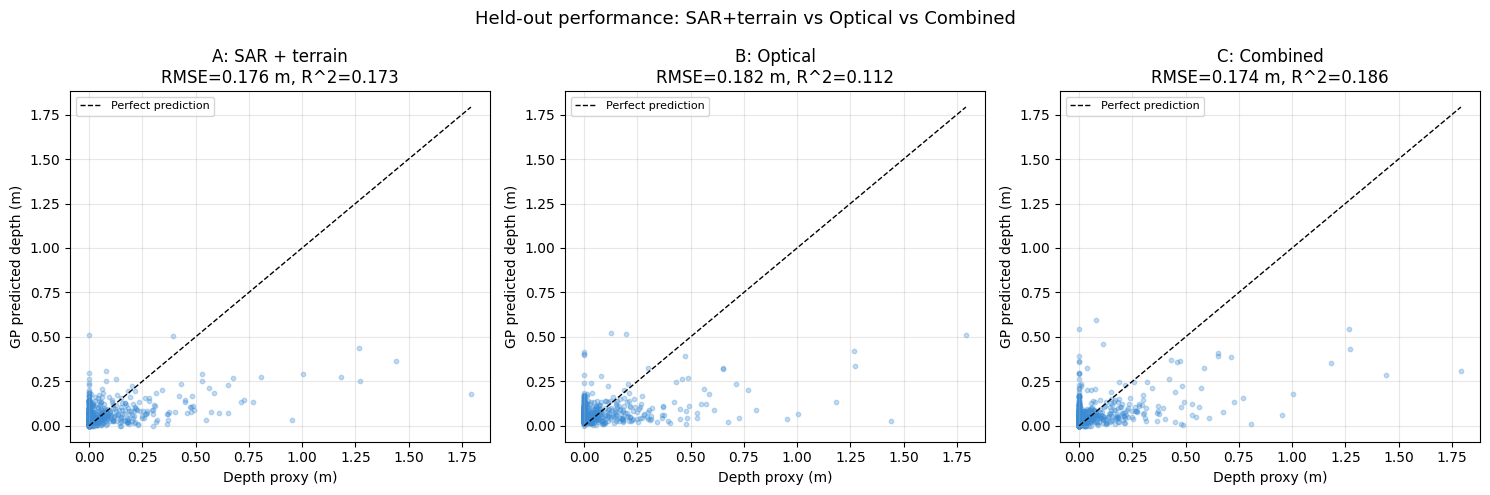

In [22]:
# One row per approach, built by a list comprehension
# Compact way to show results dictionary in compact table
perf_table = pd.DataFrame([
    {'Approach': name, 'Features': len(r['feature_names']), 'RMSE (m)': r['rmse'],
     'R^2': r['r2'], 'CO2 (g)': r['emissions'] * 1000}
    for name, r in results.items()
])
display(perf_table.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, r) in zip(axes, results.items()):
    # zip(axes, results.items()) pairs each subplot axis with one (name, r) from results
    ax.scatter(r['y_test_true'], r['mean_test'], alpha=0.3, s=10, color='#3B8BD4')
    # Scatter plot showing true depth proxy value (x) and GP's predicted depth (y)
    lims = [0, max(r['y_test_true'].max(), r['mean_test'].max())]
    # Perfect prediction reference line y=x
    # points on this line woul dmean that prediction = the exact 'true' value
    # points below it = under predicted depth, points above = over predicted
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Depth proxy (m)')
    ax.set_ylabel('GP predicted depth (m)')
    ax.set_title(f"{name}\nRMSE={r['rmse']:.3f} m, R^2={r['r2']:.3f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Inspect the performance on these graphs - varies between the three
# Performance will likely be not on the whole amazing - but we can compare between the 3
plt.suptitle('Held-out performance: SAR+terrain vs Optical vs Combined', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig15_GP_comparison_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Figure Observations 12:**
>
> - All three panels show predictions compressed well below the 1:1 perfect-prediction line for proxy depths beyond roughly 0.25-0.5 m, with predicted depth rarely exceeding ~0.5 m even where the true proxy reaches up to 1.8 m. This under-prediction at the high end is a dominant visual pattern across all three approaches.
> - This pattern follows directly from the target distribution noted in Figure Observations 11: with roughly 48% of labels at exactly zero and a long, thin tail of large but rare values, a GP minimising squared error in log1p space will be pulled toward the dense, low-value mode and under-predict the sparse high-value tail.
> - The differences between approaches are real but small relative to this shared limitation. R^2 ranges from worst at 0.112 (Optical) to best at 0.186 (Combined).
> - The single rightmost point in each panel (true depth proxy ≈ 1.79 m, almost certainly within the river channel) is predicted at only 0.18-0.51 m across all three approaches, the largest error in the dataset. This demonstrates that a small number of high-leverage pixels disproportionately drive the RMSE figures quoted in Section 3.5.
> - As Optical (B) shows a similar degree of compression to A and C, despite drawing on an entirely different feature set, the limitation likely lies more in the inherent difficulty of the regression target itself than in the shortcomings of any one feature set.

## 3.6 What Each Approach Relies On: ARD Lengthscale Comparison

For each approach, shorter lengthscales (higher 1/lengthscale) mean the GP's prediction is more sensitive to that feature. The three panels let us compare, within and across approaches, what each one is actually relying on:

- Within **A**, whether `VV_diff`/`VV_mid` dominate, or whether terrain (`elevation`, `slope`) carries real weight for *depth* even though it played no role in *detecting* the flood.
- Within **B**, which optical feature is most informative - one of the raw bands, NDWI/MNDWI, or the Stumpf ratio.
- In **C**, when both SAR/terrain and optical features are available together, which group's features remain relevant. If a SAR feature and an optical feature are both highly ranked in C and represent genuinely different information, that's evidence for using both; if one group's features drop to long lengthscales once the other group is present, that group was carrying redundant information.

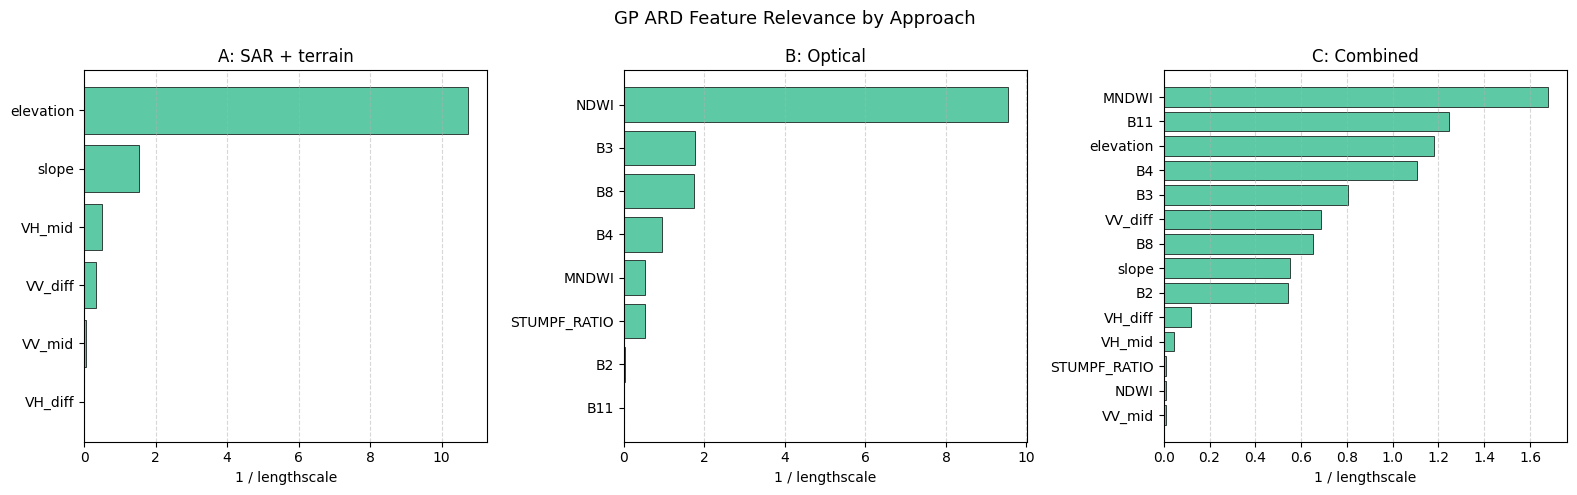


A: SAR + terrain - top 3 most relevant features:


,Feature,Lengthscale,1/Lengthscale
4,elevation,0.093067,10.744980
5,slope,0.649389,1.539908
1,VH_mid,1.970559,0.507470



B: Optical - top 3 most relevant features:


,Feature,Lengthscale,1/Lengthscale
5,NDWI,0.104814,9.540748
1,B3,0.568243,1.759812
3,B8,0.575377,1.737992



C: Combined - top 3 most relevant features:


,Feature,Lengthscale,1/Lengthscale
12,MNDWI,0.596064,1.677671
10,B11,0.802134,1.246675
4,elevation,0.847867,1.179431


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ard_tables = {} # stores each approach's lengthscale table for the printed top-3 summary shown
for ax, (name, r) in zip(axes, results.items()):
    # uses recursive helper from earlier to pull per-feature lengthscale array out of the approach's fitted kernel
    lengthscales = get_ard_lengthscales(r['kernel'])
    df = pd.DataFrame({
        'Feature': r['feature_names'],
        'Lengthscale': lengthscales,
        # 1/lengthscale = a short lengthscale becomes a large 1/lengthscale value
        # so that the most relevant features are the longest bars now
        '1/Lengthscale': 1.0 / lengthscales,
    }).sort_values('1/Lengthscale', ascending=True) # largest value ends up at top
    ard_tables[name] = df

    ax.barh(df['Feature'], df['1/Lengthscale'], color='#5DCAA5', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('1 / lengthscale')
    ax.set_title(name)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('GP ARD Feature Relevance by Approach', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig16_GP_ARD_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# For each approach, print and display just the top 3 features
# Good for easy interpretation alongside the more detailed visual bar charts
for name, df in ard_tables.items():
    print(f"\n{name} - top 3 most relevant features:")
    display(df.sort_values('1/Lengthscale', ascending=False).head(3))

> **Figure Observations 13:**
>
> - In **A (SAR + terrain)**, `elevation` dominates by a clear margin (1/lengthscale ≈ 10.7, roughly seven times `slope`, its nearest competitor), with all four SAR-derived features ranking below both terrain features. This is partly due to how the depth proxy itself is defined, rather than a physical feature: the depth proxy is derived from elevation differences (Section 3.3), so elevation's dominance reflects that.
> - In **B (Optical)**, `NDWI` dominates by a similar margin (≈5x `B3` and `B8`, its nearest competitors), while `MNDWI` ranks only 5th of 8 - of the two water indices available, NDWI carries most of the depth-related signal in this approach.
> - In **C (Combined)**, no single feature dominates: the top three (`MNDWI`, `B11`, `elevation`) are closely bunched (1/lengthscale 1.68, 1.25, 1.18), indicating a more distributed reliance across features. `NDWI` - dominant in B - falls to 13th of 14, while `MNDWI` and `B11` (5th and last in B, respectively) rise to 1st and 2nd.
> - This reordering may be a multicollinearity artefact rather than an actual distinction between the two indices: NDWI and MNDWI are computed from overlapping bands (both use `B3`, the difference is `B8` vs `B11`), and with 14 correlated features fitted to a training set capped at 1,500 pixels (Section 3.4), ARD optimisation can distribute credit for a shared signal somewhat arbitrarily between correlated predictors. The more realistic interpretation is that some `B3`-based water index remains relevant in C, rather than that MNDWI specifically matters while NDWI does not.
> - `elevation`'s sensitivity also falls substantially in C (1/lengthscale 10.7 in A to 1.18 in C, a roughly ninefold reduction), consistent with C also being the best-performing approach overall, albeit by a small margin (R^2 = 0.186 vs 0.173 for A and 0.112 for B; Section 3.5). This suggests part of elevation's explanatory role in A is picked up by the optical features once they are made available in C.

## 3.7 Full Depth and Uncertainty Maps for the Best Approach

We take the approach with the highest held-out R^2, refit it on all flooded pixels (we've already evaluated generalisation in Section 3.5), and produce full depth and uncertainty maps. Areas of high predictive uncertainty are where the GP has seen few similar feature combinations during training, typically near the edges of the flood extent.

Best approach by held-out R^2: C: Combined (R^2 = 0.186, RMSE = 0.174 m)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 10 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Con

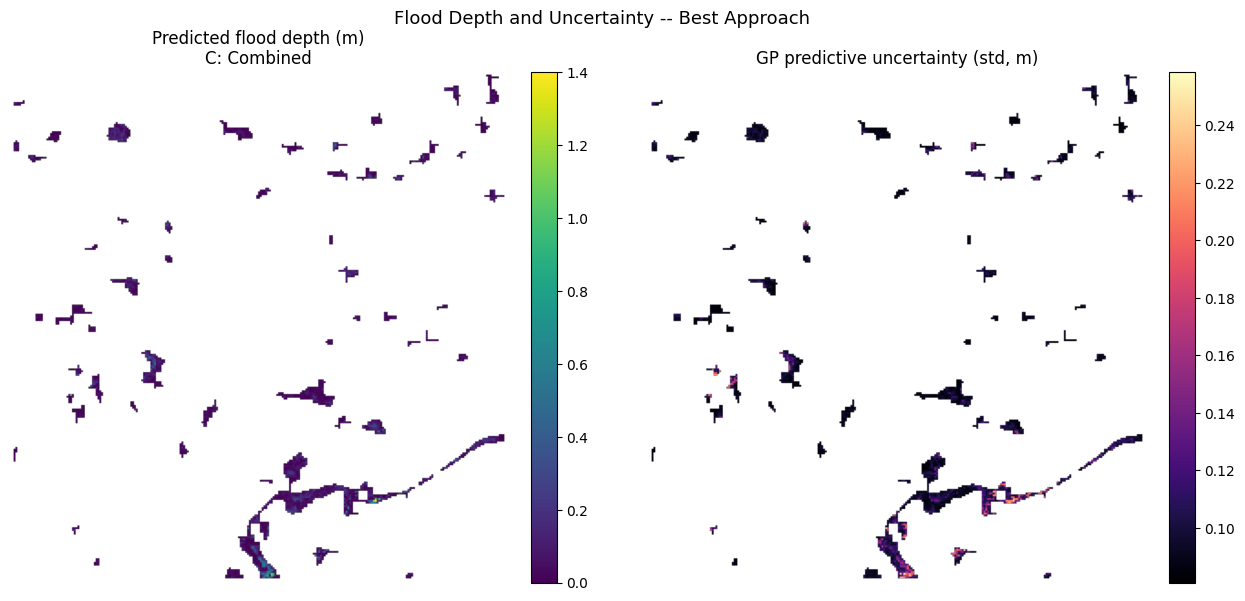

In [24]:
# THIS CELL TAKES THE 2nd LONGEST OF PROJECT - 10+ MINS

# best_name = the name of the approach (A, B, or C) that had the highest held out R^2
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
print(f"Best approach by held-out R^2: {best_name} (R^2 = {best['r2']:.3f}, RMSE = {best['rmse']:.3f} m)")

# Rebuild the full feature matrix for the winning approach's feature set
X_full = build_X(best['feature_names'])
X_full_scaled = best['X_scaler'].transform(X_full)
y_full_log = np.log1p(y_full)
y_full_scaled = best['y_scaler'].transform(y_full_log.reshape(-1, 1)).flatten()

# MAX_GP_TRAIN subsampling again but applied to whole dataset (all flooded pixels)
# Refitting a GP to produce final map below
if len(X_full_scaled) > MAX_GP_TRAIN:
    fit_idx = np.random.default_rng(42).choice(len(X_full_scaled), MAX_GP_TRAIN, replace=False)
else:
    fit_idx = np.arange(len(X_full_scaled))

# A fresh Gaussian Process with same kernel structure/bounds as before, but reoptimised
# Uses slightly different/larger sample to produce best possible final map
gp_full = GaussianProcessRegressor(
    kernel=make_kernel(X_full_scaled.shape[1]),
    normalize_y=False, n_restarts_optimizer=2, random_state=42,
)
gp_full.fit(X_full_scaled[fit_idx], y_full_scaled[fit_idx])

# Predict mean and sttandard deviation for each flooded pixel
# provides per-pixel uncertainty estimates
mean_all_scaled, std_all_scaled = gp_full.predict(X_full_scaled, return_std=True)
# Undo the y-scaling for the mean (back to log1p-space)
mean_all_log = best['y_scaler'].inverse_transform(mean_all_scaled.reshape(-1, 1)).flatten()
std_all_log = std_all_scaled * best['y_scaler'].scale_[0] # multiplying std by y_scaler.scale_[0] converts to std in log1p space

# expm1 converts the mean prediction from log1p-space back to metres
depth_pred = np.clip(np.expm1(mean_all_log), 0, None)
# First-order (delta-method) approximation: d(expm1)/dx = exp(x)
# The delta method approximates how a standard deviation transforms under a non-linear function
# only  an approximation (works mainly for small std) but good for visualisation of relative uncertainty
depth_std = np.exp(mean_all_log) * std_all_log

# Reconstruct full (H, 1) maps, starting with all-NaN, then filling predicted values at flood_mask
depth_pred_map = np.full((H, W), np.nan)
depth_std_map  = np.full((H, W), np.nan)
depth_pred_map[flood_mask] = depth_pred
depth_std_map[flood_mask]  = depth_std

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

im0 = axes[0].imshow(depth_pred_map, cmap='viridis')
axes[0].set_title(f'Predicted flood depth (m)\n{best_name}', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# using 'magma' colourmap for uncertainty
# brighter = higher predictive standard deviation (GP less confident)
# often less certain near the edges of flooded regions
im1 = axes[1].imshow(depth_std_map, cmap='magma')
axes[1].set_title('GP predictive uncertainty (std, m)', fontsize=12)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('Flood Depth and Uncertainty -- Best Approach', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig17_depth_uncertainty_best.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Figure Observations 14:**
>
> - The predicted depth map is visually almost uniform near zero across the flooded extent; the colour scale's upper bound (1.4 m) is barely used, with the only visible departure from dark purple being a small cluster near the river confluence at the bottom of the AOI.
> - GP predictive uncertainty follows a similar pattern: almost all pixels sit near the low end of their own colour scale, with a tight cluster of much higher uncertainty concentrated at the same river-confluence location as the highest predicted depths. This matches the expected GP behaviour described in the section's introduction - uncertainty rises where training data is sparser or feature combinations are less typical - and here coincides with the few pixels carrying the most unusual depth values.
> - In absolute terms, however, the uncertainty range (roughly 0.09-0.26 m) is not small relative to the predicted depths themselves, many of which fall below 0.2 m. At the pixel level, this means the GP's confidence band can be comparable in magnitude to the prediction it is attached to.


## 3.8 Unsupervised Cross-Check: K-Means on Water-Colour Features

Here, K-means clusters group flooded pixels by their **optical water-colour features alone** (no depth proxy or labels). If the resulting clusters correspond to systematically different depth-proxy values, that is evidence that water colour carries depth-related information, independently of the GP regressions: the clustering is computed without reference to the depth proxy or to any of the GP results.

We use k=3, anticipating something like "shallow/turbid", "intermediate", and "deep/clear" water-colour classes - but the cluster order by depth is determined entirely by K-means.

/tmp/ipykernel_3630/586390883.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=[f'Cluster {k}' for k in range(K)])


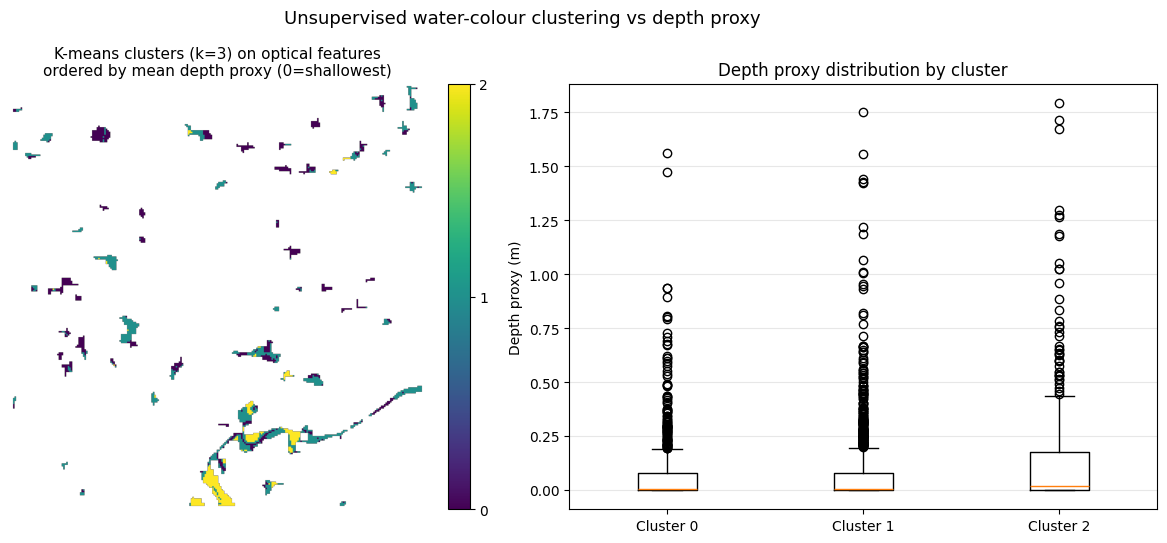

,Cluster,N pixels,Mean depth proxy (m),Mean B2,Mean B3,Mean B4,Mean B8,Mean B11,Mean NDWI,Mean MNDWI,Mean STUMPF_RATIO
0,0,981,0.067,0.021,0.054,0.040,0.305,0.141,-0.695,-0.448,1.330
1,1,1324,0.078,0.029,0.048,0.058,0.135,0.106,-0.442,-0.341,1.175
2,2,463,0.136,0.047,0.074,0.086,0.048,0.018,0.254,0.641,1.179


In [25]:
K = 3 # number of clusters

# Build a feature matrix from the 8 optical features, then standardise
X_optical = build_X(OPTICAL_FEATURES)
X_optical_scaled = StandardScaler().fit_transform(X_optical)

# n_init=10 - run 10 times from different random starts + keeping the best
# means result is more stable + reproducible
# random_state=42 -> seeds those 10 random starts
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
# fit_predict fits the cluster centres and returns which cluster each pixel is assigned to
cluster_labels = kmeans.fit_predict(X_optical_scaled) # this is unsupervised!

# Order clusters by their mean depth proxy, for a consistent reading
# K-means cluster IDs (0, 1, 2) are arbitrary so tells us nothing about what each group means
# grouping by depth means we can more intuitively interpret
cluster_depth_means = [y_full[cluster_labels == k].mean() for k in range(K)]
order = np.argsort(cluster_depth_means)
relabel = {old: new for new, old in enumerate(order)} # we relabel in order of depth
cluster_labels_ordered = np.array([relabel[c] for c in cluster_labels])

# Reconstruct a (H, W) map of relabelled cluster assignments
cluster_map = np.full((H, W), np.nan)
cluster_map[flood_mask] = cluster_labels_ordered

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# vmin=0, vmax=K-1 fixes the colour scale to the k-means values
im0 = axes[0].imshow(cluster_map, cmap='viridis', vmin=0, vmax=K - 1)
axes[0].set_title(f'K-means clusters (k={K}) on optical features\n'
                   f'ordered by mean depth proxy (0=shallowest)', fontsize=11)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=range(K))

# box_data is a list of arrays, with one per cluster - so we can make a boxplot
box_data = [y_full[cluster_labels_ordered == k] for k in range(K)]
axes[1].boxplot(box_data, tick_labels=[f'Cluster {k}' for k in range(K)])
axes[1].set_ylabel('Depth proxy (m)')
axes[1].set_title('Depth proxy distribution by cluster')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Unsupervised water-colour clustering vs depth proxy', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig18_kmeans_water_colour.png'), dpi=150, bbox_inches='tight')
plt.show()

# A summary table for each cluster with how many pixels, mean depth proxy, and the mean of each optical feature
cluster_summary = pd.DataFrame({
    'Cluster': range(K),
    'N pixels': [int((cluster_labels_ordered == k).sum()) for k in range(K)],
    'Mean depth proxy (m)': [y_full[cluster_labels_ordered == k].mean() for k in range(K)],
})

# Loops over each optical feature, adding a new column to cluster_summary per feature
for f in OPTICAL_FEATURES:
    arr = all_feature_arrays[f][flood_mask]
    cluster_summary[f'Mean {f}'] = [arr[cluster_labels_ordered == k].mean() for k in range(K)]

display(cluster_summary.round(3))

> **Figure Observations 15:**
>
> - Cluster 2 (the 'deepest' cluster) is concentrated along the river corridor and in a small number of other compact patches, consistent with it corresponding to open or near-open water rather than field-level ponding.
> - Mean `B8` and `B11` reflectance decrease from Cluster 0 to Cluster 2 (0.305 to 0.048, and 0.141 to 0.018 respectively), while `NDWI` and `MNDWI` only become positive (water-like) in Cluster 2. Both indices flip sign at the same point in the ordering, but `MNDWI`'s flip is considerably larger (+0.641 vs +0.254 for NDWI).
> - `STUMPF_RATIO` is effectively flat between Clusters 1 and 2 (1.175 vs 1.179), corroborating the earlier finding (Section 3.11) that this index seems to carry no comparable depth-related signal in this setting.
> - The clearest separation in the boxplot is between {Cluster 0, Cluster 1} and Cluster 2, rather than a clean three-way shallow/intermediate/deep gradient. Clusters 0 and 1 have similar mean depth proxies (0.067 m and 0.078 m) and substantially overlapping distributions, while Cluster 2 sits visibly higher and also contains the most extreme outliers (up to ~1.8 m) despite being the smallest cluster by pixel count (463, against 981 and 1,324). This suggests that K = 3 is effectively recovering a two-way water/non-water split here, with one of those two groups further subdivided, rather than three actually distinct depth regimes.

## 3.9 XAI Cross-Check: SHAP on a Random Forest Depth Regressor

As a second, independent feature-importance method, a Random Forest regressor is trained on the combined feature set (Approach C) against the same depth-proxy target, and SHAP values are computed for its predictions. If SHAP's ranking broadly agrees with the GP's ARD lengthscales for Approach C (Section 3.6), this would represent two substantially different models - a Gaussian Process and a tree ensemble - independently arriving at a similar account of what matters for depth, which is considerably stronger evidence than either method could provide alone.

[codecarbon WARNING @ 19:08:22] Already started tracking
[codecarbon WARNING @ 19:09:44] Tracker already stopped !


SHAP values computed for 2,768 pixels.
CO2 emissions (SHAP computation): 5.4254 g CO2e


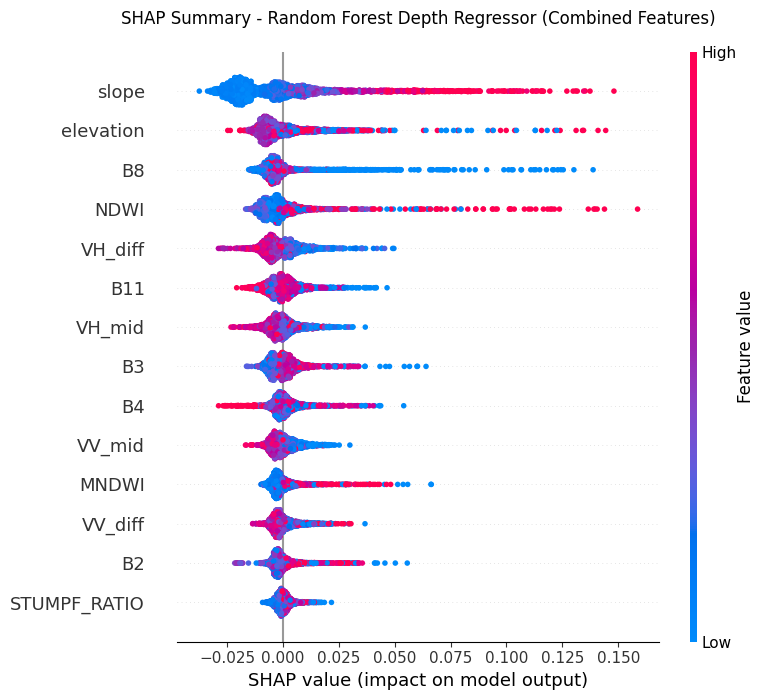

,Feature,Mean |SHAP value|
5,slope,0.019317
4,elevation,0.009270
9,B8,0.007989
11,NDWI,0.007811
3,VH_diff,0.006282
10,B11,0.005268
1,VH_mid,0.004827
7,B3,0.004697
8,B4,0.004340
0,VV_mid,0.004231


In [26]:
# Same COMBINED_FEATURES (14) but to look at an independent feature-importance method
X_combined = build_X(COMBINED_FEATURES)

# A random forest regressor (like in Notebook 2) but predicting continuous depth value not flood/not flood class
rf_depth = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, max_features='sqrt',
    random_state=42, n_jobs=-1,
)

# Fit on all flooded pixels to support SHAP feature-importance analysis
rf_depth.fit(X_combined, y_full)

tracker.start() # track SHAP's computation cost
SHAP_SAMPLE_SIZE = min(3000, X_combined.shape[0]) # capping at 3000 or fewer keeps it fast but representative
rng = np.random.default_rng(42)
shap_idx = rng.choice(X_combined.shape[0], SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_combined[shap_idx]

# .TreeExplainer is SHAP implementation specialised for tree-based models (e.g. RF)
# exploits tree structure to calculate SHAP values
explainer = shap.TreeExplainer(rf_depth)
# For each of 3000 sampled pixels + each of 14 features, shap_values gives the features contribution to that specific pixel
shap_values = explainer.shap_values(X_shap)
shap_emissions = tracker.stop()

print(f"SHAP values computed for {SHAP_SAMPLE_SIZE:,} pixels.")
print(f"CO2 emissions (SHAP computation): {shap_emissions*1000:.4f} g CO2e")

# A 'bee swarm' plot, each dot= one sampled pixel
# A dots horizontal position is the pixel's SHAP value for that feature
# Colour of dot = whether value of feature was high (red) or low (blue)
shap.summary_plot(shap_values, X_shap, feature_names=COMBINED_FEATURES, show=False)
plt.title('SHAP Summary - Random Forest Depth Regressor (Combined Features)', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig19_SHAP_depth_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

# Converts bee swarm's information into an average importance number across all sampled pixels
# Looks at how large of an impact the feature had on the prediction
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': COMBINED_FEATURES,
    'Mean |SHAP value|': mean_abs_shap,
}).sort_values('Mean |SHAP value|', ascending=False)

display(shap_importance)

> **Figure Observations 16:**
>
> - `slope` ranks 1st by mean |SHAP value|, ahead of `elevation` (2nd) - a result that differs from Approach C's ARD ranking (Figure Observations 13), where `elevation` ranked 3rd overall and `slope` did not appear in the combined approach's top three. This is a point of partial disagreement between the two explainability methods, alongside the optical-feature divergence.
> - For `slope`, high feature values (red) are associated with strongly positive SHAP values, i.e. steeper local terrain is associated with higher predicted depth. This is not immediately intuitive, as flatter ground might be expected to pool more water, but is likely an artefact of the depth proxy's own definition (Section 3.3): the steepest elevation drop to the nearest dry pixel, and therefore the largest proxy depth, is more likely to occur precisely where local slope is highest.
> - `B8` and `NDWI` show essentially mirrored colour patterns (high `B8` associates with negative SHAP, high `NDWI` with positive SHAP), which makes sense because NDWI is partly defined by `B8`, and water surfaces are characterised by low NIR reflectance together with high NDWI.
> - `STUMPF_RATIO`, the lowest-ranked feature, shows a visibly narrow, tightly clustered swarm with little spread and no clear colour-SHAP relationship - visually confirming its position as the least informative feature, consistent with both the ARD ranking (Figure Observations 13) and the K-means cluster summary (Figure Observations 15).

## 3.10 Environmental Cost

All training runs across Notebooks 2 and 3 have logged to the same `emissions_log.csv` via CodeCarbon. We summarise the total here, broken down by project (notebook section).

In [27]:
# emissions_log.csv accumulated the rows from every EmissionsTracker.start()/.stop() cycle
# The runs are distinguished by 'project_name' column -> Flood_Model_Comparison is Notebook 2, Flood_Model_Regression is this notebook)
# You may notice another project name - Flood_Model_Classification -> this was an old notebook iteration
emissions_path = os.path.join(DIRS['results'], 'emissions_log.csv')

if os.path.exists(emissions_path):
    emissions_df = pd.read_csv(emissions_path)
    # Shows the raw log, one row per tracked run, with estimated emissions
    display(emissions_df[['timestamp', 'project_name', 'duration', 'emissions', 'energy_consumed']])

    by_project = emissions_df.groupby('project_name').agg(
        runs=('emissions', 'count'),
        total_duration_s=('duration', 'sum'),
        total_emissions_g=('emissions', lambda x: x.sum() * 1000),
        total_energy_Wh=('energy_consumed', lambda x: x.sum() * 1000),
    ).reset_index()
    display(by_project.round(4))

    # Totals across all rows (all tracked emissions overall)
    total_emissions_g = emissions_df['emissions'].sum() * 1000
    total_energy_wh   = emissions_df['energy_consumed'].sum() * 1000
    total_duration_s  = emissions_df['duration'].sum()

    print(f"\nTotal across all tracked runs (Notebooks 2-3):")
    print(f"  Training time:    {total_duration_s:.1f} s")
    print(f"  Energy consumed:  {total_energy_wh:.4f} Wh")
    print(f"  CO2 emissions:    {total_emissions_g:.4f} g CO2e")
else:
    # If emissions log has been deleted, or Notebook 2 not run yet, this should alert you
    print("emissions_log.csv not found - ensure Notebook 2 was run with CodeCarbon enabled.")

,timestamp,project_name,duration,emissions,energy_consumed
0,2026-06-13T22:26:47,Flood_RF_Classification,15.435013,0.000052,0.000111
1,2026-06-13T22:27:44,Flood_RF_Classification,72.919951,0.000207,0.000439
2,2026-06-13T22:49:10,Flood_RF_Classification,25.417902,0.000088,0.000188
3,2026-06-13T22:49:42,Flood_RF_Classification,57.418905,0.000203,0.000432
4,2026-06-13T23:38:03,Flood_Model_Comparison,20.185290,0.000021,0.000095
...,...,...,...,...,...
62,2026-06-16T18:35:56,Flood_Model_Comparison,53.884633,0.000061,0.000212
63,2026-06-16T18:42:22,Flood_Depth_Regression,309.412416,0.000987,0.002096
64,2026-06-16T18:46:27,Flood_Depth_Regression,554.771914,0.001702,0.003616
65,2026-06-16T18:55:37,Flood_Depth_Regression,1104.307851,0.003165,0.006723


,project_name,runs,total_duration_s,total_emissions_g,total_energy_Wh
0,Flood_Depth_Regression,35,32199.6872,76.2477,200.5293
1,Flood_Model_Comparison,28,989.4907,4.5098,9.1264
2,Flood_RF_Classification,4,171.1918,0.5505,1.1694



Total across all tracked runs (Notebooks 2-3):
  Training time:    33360.4 s
  Energy consumed:  210.8251 Wh
  CO2 emissions:    81.3080 g CO2e


### Discussion: Environmental Cost in Context

The figure above covers training **eight models** (RF, SVM, and CNN in Notebook 2; three GPs, a Random Forest regressor, and the SHAP computation in this notebook) plus adding an entire second data source (Sentinel-2). Across both notebooks, CodeCarbon recorded a combined total of **210.83 Wh** and **81.31 g CO2e** - roughly equivalent to 630 m of driving in an average UK car [(UK DEFNZ, 2024)](https://www.gov.uk/government/publications/greenhouse-gas-reporting-conversion-factors-2024).

This figure is a useful lower bound, not a full account. It excludes Notebook 1 (untracked), repeated runs during development, the author's own laptop use while writing this project, and debugging using the integrated Google Gemini assistant in Google Colab. It also implies a carbon intensity (~~367 g CO2/kWh) noticeably higher than the UK grid average (~126 g CO2/kWh in 2025) - since Colab's underlying hardware location isn't visible to the user, this measured figure may itself be an overestimate relative to running the same code on a UK-based machine.

More broadly, this project's compute sits within a global data centre footprint that the [IEA](https://www.iea.org/reports/energy-and-ai/energy-demand-from-ai) estimates at ~1.5% of global electricity (2024), growing roughly four times faster than overall demand - alongside considerations like water use for cooling and the geographic concentration of that demand in specific regions.

A fuller discussion, including these wider considerations and sourced comparisons, is provided in [`ENVIRONMENTAL_COST.md`](ENVIRONMENTAL_COST.md) in the project repository.

**Comparison with traditional flood depth surveying**: estimating flood depth across an area this size by traditional means would require either wading/boat-based depth gauging at many points, or LiDAR survey flights - which would likely be both more carbon- and labour-intensive than the CodeCarbon total above. However, a number of factors contribute to the environmental cost of this workflow, which are further discussed in the repository markdown document.

## 3.11 Conclusions, Limitations, and Real-World Quantification

We can attempt to translate the best approach's depth map into a total flood volume that gives gives a more tangible sense of scale than RMSE/R^2 alone. We do this by comparing with the approximate volume of an Olympic swimming pool...

In [28]:
# pixel_area_m2 -> each pixel represents a SCALE x SCALE metre squared on the ground
# here pixel is 400m^2 at this project's resolution
pixel_area_m2 = SCALE ** 2

# Total flooded area = number of flooded pixels x area per pixel
flood_area_m2 = int(flood_mask.sum()) * pixel_area_m2

# Estimated total flood volume, np.nansum ignores NaNs
flood_volume_m3 = np.nansum(depth_pred_map) * pixel_area_m2

OLYMPIC_POOL_M3 = 2500  # approx volume of an Olympic swimming pool in m^3

print(f"Flood extent (cleaned mask):       {flood_area_m2/1e6:.3f} km^2") # m^2 to km^2 needs dvide by 1e6
print(f"Mean predicted depth:        {np.nanmean(depth_pred_map):.2f} m")
print(f"Estimated total flood volume: {flood_volume_m3:,.0f} m^3")

# We attempt to make real-world figure translation of this abstract volume figure
# Using the olympic swimming pools set out above
print(f"  ~ equivalent to {flood_volume_m3/OLYMPIC_POOL_M3:,.0f} Olympic swimming pools")
print(f"\nBest approach: {best_name} (R^2 = {best['r2']:.3f}, RMSE = {best['rmse']:.3f} m)")

# K-means summary with min()/max() report of the spread between clusters to compare
print(f"K-means water- colour clusters: mean depth proxy ranged from "
      f"{min(cluster_depth_means):.2f} m to {max(cluster_depth_means):.2f} m across clusters")

Flood extent (cleaned mask):       1.107 km^2
Mean predicted depth:        0.08 m
Estimated total flood volume: 86,495 m^3
  ~ equivalent to 35 Olympic swimming pools

Best approach: C: Combined (R^2 = 0.186, RMSE = 0.174 m)
K-means water- colour clusters: mean depth proxy ranged from 0.07 m to 0.14 m across clusters


### Summary of results

The Sentinel-2 scene used throughout this notebook is from **18 November 2019** - ten days day after the SAR mid-flood acquisition, with ~6% cloud cover (Section 3.1).

- **Approach A (SAR + terrain)**: R^2 = 0.173, RMSE = 0.176 m. ARD ranked `elevation` far above all else (1/lengthscale ~~10.7), with `slope` a distant second (~1.5) and all four SAR-derived features ranking below both terrain features - partly definitional, given how the depth proxy itself is constructed (Section 3.3).
- **Approach B (Optical)**: R^2 = 0.112, RMSE = 0.182 m - positive, but more modest than A, despite the well-timed, low-cloud scene above. ARD ranked `NDWI` first by a wide margin, with `B3` and `B8` (the two bands NDWI is computed from) close behind in 2nd/3rd; `MNDWI` ranked only 5th of 8. That optical features alone still underperform SAR+terrain, even with a near-contemporaneous scene, is a more robust finding than it would have been with the earlier, poorly-timed scene.
- **Approach C (Combined)**: R^2 = 0.186, RMSE = 0.174 m - the best of the three, though the improvement over A is modest (+0.013 R^2, -0.0014 m RMSE). The ranking shifts substantially from B: `MNDWI` and `B11` take 1st/2nd place, `elevation` drops to 3rd (its 1/lengthscale falling from ~10.7 in A to ~1.2 in C), and `NDWI` - B's leading feature - falls to 13th of 14.
- **K-means (unsupervised)**: three water-colour clusters had mean depth proxies of 0.067, 0.078, and 0.136 m - the deepest cluster's mean depth is roughly double the shallowest's. The deepest cluster also has the lowest mean `B8` and `B11` (factors of ~6 and ~8 below the shallowest cluster respectively), and is the only cluster with positive `NDWI` (0.254) and strongly positive `MNDWI` (0.641) - both indices flip from land-like (negative) to water-like (positive) only in this deepest cluster. `STUMPF_RATIO` shows no comparable trend across clusters (1.33, 1.18, 1.18). This is an independent, label-free confirmation of the same depth-colour gradient found by the GP approaches, using a different method entirely.
- **SHAP vs ARD**: the two methods show partial, structured agreement rather than a clean match. Both rank `elevation` highly (ARD 3rd, SHAP 2nd) and `STUMPF_RATIO` lowest or near-lowest (ARD 12th/14, SHAP 14th/14). However, they diverge on which optical features matter most: ARD's top optical features for Approach C are `MNDWI` and `B11` (1st and 2nd overall), while SHAP's are `B8` and `NDWI` (3rd and 4th overall) -- `MNDWI` ranks only 11th by SHAP, and `NDWI` only 13th by ARD. Since NDWI and MNDWI are computed from overlapping bands (both use `B3`; the difference is `B8` vs `B11`), this looks like the two methods distributing 'credit' differently across a pair of correlated features, rather than a substantive disagreement about whether water-colour information matters. Read together: both methods agree that some combination of terrain and water-colour information is relevant, and that the Stumpf ratio specifically is not - but neither method's specific optical-feature ranking should be over-interpreted given this correlation.

### Limitations

1. **Depth proxy simplification**: Height Above Nearest Dry Pixel, after the morphological cleanup and DEM smoothing described in Section 3.3, assumes hydrological connectivity between a flooded pixel and its nearest dry neighbour - reasonable over a small, flat floodplain like Fishlake, but not a validated absolute depth. All R^2/RMSE figures in this notebook are relative to this proxy, not to measured depths.
2. **Multicollinearity among optical features**: NDWI and MNDWI (and, more generally, B8 and B11) are computed from overlapping bands and are highly correlated. As the SHAP vs ARD comparison above shows, this means different methods can attribute importance to different members of a correlated pair without genuinely disagreeing about whether that *type* of information matters. Conclusions in this notebook about which water-colour index is most informative should therefore be treated as less robust than conclusions about whether water-colour information is informative at all.
3. **Single training scene**: all depth modelling here uses the Fishlake training scene only. Notebook 2's spatial and temporal test scenes (Bentley/Toll Bar, Fishlake Jan 2021) were not used here, since Sentinel-2 data was only fetched for the training scene - extending the optical fetch to those scenes (Notebook 1) would allow the same cross-scene generalisation tests used for classification in Notebook 2 to be repeated for depth regression.
4. **Stumpf ratio outside its design conditions**: the blue:green log-ratio was developed for clear coastal water up to ~25 m depth; floodwater here is shallow (typically << 1 m) and likely turbid. That it ranks lowest or near-lowest by both ARD (Approach C) and SHAP - two independent methods - is consistent with this being a genuine finding about transferability, rather than an artefact of either method individually.

## 3.12 Summary

Across the three notebooks, this project has:

1. Explained and applied the **physical basis of SAR flood detection**, and produced an independently-computed baseline (Threshold Baseline) flood map for each of three scenes (Notebook 1).
2. Split the training scene into a confident core (labelled) and an ambiguous margin (unlabelled), and trained **Random Forest, SVM, and a CNN** on the confident core alone (Notebook 2).
3. Tested **spatial generalisation** (Bentley/Toll Bar, same event) and **temporal generalisation** (Fishlake, Jan 2021, different event), each against an independently-computed Threshold Baseline rather than the training scene's own labels (Notebook 2).
4. Defined a **DEM-based depth proxy** and compared **three GP regression approaches** - SAR+terrain, optical/water-colour, and combined - using **ARD lengthscales** to interpret what each relies on (this notebook).
5. Cross-checked the GP results with an **unsupervised K-means** clustering of water-colour features and with **SHAP** on an independently-trained Random Forest regressor, finding partial but structured agreement between the two explainability methods.
6. Tracked **CO2 emissions** for every model trained across Notebooks 2 and 3, and discussed the project's environmental footprint in context (Section 3.10).

Two questions ultimately shaped this work: whether classifiers trained on a SAR-threshold baseline generalise across space and time, or simply reproduce the rule they were shown; and whether Sentinel-2 optical data improves flood depth estimation beyond a DEM-derived proxy alone.

On the first, Random Forest generalised best on both axes (Spatial IoU = 0.994, Temporal IoU = 0.974), consistent with learning something close to the underlying physical rule rather than scene-specific texture. The CNN generalised worst, dropping more on the temporal test than the spatial one - suggesting it picked up something acquisition-specific rather than a transferable signal.

On the second, the Combined approach performed best (R^2 = 0.186, vs 0.173 for SAR+terrain and 0.112 for optical alone), drawing on optical features (MNDWI, B11) largely distinct from terrain - though the improvement is modest, since this floodplain's depth proxy sits close to zero across much of its extent regardless of input data.

The main caveat throughout is that all depth figures are relative to a simplified, unvalidated proxy rather than measured floodwater depth. Beyond the limitations already discussed, potential future work could include fetching Sentinel-2 for the spatial and temporal test scenes to cross-scene test depth regression as Notebook 2 did for classification, and validating the proxy itself against any available field or LiDAR-derived ground truth.

---
*GEOL0069 Final Project | UCL AI for Earth Observation 2025/26*

[GEOL0069 @ UCL 2025/26](https://github.com/CPOMUCL/GEOL0069-AI4EO)

---